## **CLEANING PHASE**

In [1]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Step 1 - Load the data and do an inspection first

In [1]:
import pandas as pd

df = pd.read_csv("../data/raw_data.csv")

print(df.shape)

#shows you column dtypes, non-null counts per column
df.info()
df.head(3)

#clean per-column count of missing values
df.isnull().sum()

(418, 8)
<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   title        418 non-null    str  
 1   company      418 non-null    str  
 2   location     366 non-null    str  
 3   tags         418 non-null    str  
 4   description  418 non-null    str  
 5   apply_url    418 non-null    str  
 6   date_posted  418 non-null    str  
 7   search_tag   418 non-null    str  
dtypes: str(8)
memory usage: 26.3 KB


title           0
company         0
location       52
tags            0
description     0
apply_url       0
date_posted     0
search_tag      0
dtype: int64

Step 2 - Handle Missing values

In [2]:
df["company"] = df["company"].fillna("Not specified")
df["location"] = df["location"].fillna("Not specified")
df["tags"] = df["tags"].fillna("")
df["description"] = df["description"].fillna("")

Step 3 - Drop duplicate postings

In [3]:
before = len(df)
df = df.drop_duplicates(subset=["title", "company", "apply_url"]) #The apply URL is unique per posting
after = len(df)
print(f"Removed {before - after} duplicate rows")

Removed 0 duplicate rows


Step 4 - Lowercase and strip text columns

In [4]:
text_cols = ["title", "company", "location", "tags", "description"]

#.astype(str) guarantees that every value is text
for col in text_cols:
    df[col] = df[col].astype(str).str.lower().str.strip()

Step 5 - Remove leftover HTML/whitespace artifacts

In [5]:
import re

def clean_text_artifacts(text):
    text = re.sub(r"\s+", " ", text)      # collapse multiple spaces/newlines into one
    text = text.replace("\xa0", " ")       # remove non-breaking space characters
    text = text.strip()
    return text

for col in text_cols:
    df[col] = df[col].apply(clean_text_artifacts)

Step 6 - Check the result

In [6]:
df[["title", "company", "location", "description"]].sample(5)

,title,company,location,description
303,creative,the elites,"london,","we are wiser, a global, award-winning employer..."
348,territory business development manager usmc,shield ai,remote,"founded in 2015, shield ai is a venture-backed..."
102,ai filmmaker,foxelli group,"praha, praha, hlavnã­ mästo praha, äesko",please be informed that foxelli group hires ex...
147,cyber operations management system demonstrati...,"emw, inc.",not specified,deadline date: monday 22 june 2026 requirement...
305,profesor a de apoyo escolar todos los niveles,apprentus,"sevilla,",buscamos profesores / tutores para refuerzo es...


In [7]:
print((df["description"].str.len() < 20).sum(), "postings have very short descriptions")

0 postings have very short descriptions


Step 7 - Save the cleaned version

In [8]:
df.to_csv("../data/cleaned_data.csv", index=False)
print(f"Final cleaned dataset: {len(df)} rows")

Final cleaned dataset: 418 rows


## **SKILLS EXTRACTION**

Step 1 - Load you cleaned data

In [9]:
import pandas as pd
import re

df = pd.read_csv("../data/cleaned_data.csv")
df.shape

(418, 8)

Step 2 - Define you skill list, grouped by category

In [10]:
technical_skills = [
    "python", "sql", "r", "java", "javascript", "c++", "c#", "scala",
    "excel", "power bi", "tableau", "looker",
    "aws", "azure", "gcp", "docker", "kubernetes",
    "machine learning", "deep learning", "nlp", "statistics",
    "spark", "hadoop", "airflow", "git", "linux",
    "figma", "photoshop", "seo", "html", "css"
]

soft_skills = [
    "communication", "collaboration", "teamwork", "leadership",
    "problem solving", "stakeholder management", "critical thinking",
    "time management", "adaptability", "presentation"
]

Step 3 - Word-boundary matching

In [11]:
def skill_present(description, skill):
    """
    Checks if a skill appears as a standalone word/phrase,
    using lookaround instead of \\b so it works correctly even
    for skills ending in symbols like 'c++' or 'c#'.
    """
    pattern = r"(?<!\w)" + re.escape(skill) + r"(?!\w)"
    return bool(re.search(pattern, description))

In [12]:
sample = df["description"].iloc[0] 
print(skill_present(sample, "python"))
print(skill_present(sample, "r"))

False
False


Step 4 - Build one boolean column per skill

In [13]:
for skill in technical_skills:
    df[skill] = df["description"].apply(lambda desc: skill_present(desc, skill))

for skill in soft_skills:
    df[skill] = df["description"].apply(lambda desc: skill_present(desc, skill))

Step 5 - Small check

In [14]:
df[["title"] + technical_skills[:5]].sample(5)

,title,python,sql,r,java,javascript
149,data processing specialist,False,False,False,False,False
320,senior vice president global operations,False,False,False,False,False
107,meeting coordinator,False,False,False,False,False
365,staff product manager enterprise,False,False,False,False,False
196,data analyst,True,True,True,False,False


Step 6 - Count skill frequency across all postings

In [15]:
#Technical Skills Count
skill_counts = df[technical_skills].sum().sort_values(ascending=False)
print(skill_counts)

sql                 50
excel               48
python              46
aws                 17
power bi            15
figma               15
azure               13
machine learning    13
git                 13
tableau             12
r                   12
statistics          10
gcp                 10
linux                9
looker               8
javascript           8
html                 8
spark                7
java                 7
css                  7
seo                  7
kubernetes           7
docker               7
c#                   4
photoshop            4
scala                3
c++                  3
airflow              3
nlp                  1
hadoop               0
deep learning        0
dtype: int64


In [16]:
#Soft Skills Count
soft_counts = df[soft_skills].sum().sort_values(ascending=False)
print(soft_counts)

communication             175
leadership                 91
collaboration              74
time management            21
presentation               21
teamwork                   19
adaptability               15
stakeholder management     12
problem solving            10
critical thinking           4
dtype: int64


Step 7 - Convert counts to percentages

In [17]:
#Technical skills percentages
total_postings = len(df)
skill_percentages = (skill_counts / total_postings * 100).round(1)
print(skill_percentages)

sql                 12.0
excel               11.5
python              11.0
aws                  4.1
power bi             3.6
figma                3.6
azure                3.1
machine learning     3.1
git                  3.1
tableau              2.9
r                    2.9
statistics           2.4
gcp                  2.4
linux                2.2
looker               1.9
javascript           1.9
html                 1.9
spark                1.7
java                 1.7
css                  1.7
seo                  1.7
kubernetes           1.7
docker               1.7
c#                   1.0
photoshop            1.0
scala                0.7
c++                  0.7
airflow              0.7
nlp                  0.2
hadoop               0.0
deep learning        0.0
dtype: float64


In [18]:
#Soft skills percentages
soft_percentages = (soft_counts / total_postings * 100).round(1)
print(soft_percentages)

communication             41.9
leadership                21.8
collaboration             17.7
time management            5.0
presentation               5.0
teamwork                   4.5
adaptability               3.6
stakeholder management     2.9
problem solving            2.4
critical thinking          1.0
dtype: float64


In [19]:
combined_percentages = pd.concat([skill_percentages, soft_percentages]).sort_values(ascending=False)
print(combined_percentages)

communication             41.9
leadership                21.8
collaboration             17.7
sql                       12.0
excel                     11.5
python                    11.0
time management            5.0
presentation               5.0
teamwork                   4.5
aws                        4.1
power bi                   3.6
adaptability               3.6
figma                      3.6
git                        3.1
machine learning           3.1
azure                      3.1
tableau                    2.9
stakeholder management     2.9
r                          2.9
statistics                 2.4
gcp                        2.4
problem solving            2.4
linux                      2.2
javascript                 1.9
looker                     1.9
html                       1.9
css                        1.7
docker                     1.7
kubernetes                 1.7
seo                        1.7
spark                      1.7
java                       1.7
c#      

Step 8 - Save the skill-augmented dataset

In [20]:
df.to_csv("../data/skills_data.csv", index=False)
print("Saved skills_data.csv with", len(df), "rows and", len(df.columns), "columns")

combined_percentages.to_csv("../data/skill_percentages.csv", header=["percentage"])
print("Saved skill_percentages.csv")

Saved skills_data.csv with 418 rows and 49 columns
Saved skill_percentages.csv


## EDA & Visualization

In [4]:
%pip install matplotlib seaborn

     ---------------------------------------- 0.0/80.3 kB ? eta -:--:--
     ----- ---------------------------------- 10.2/80.3 kB ? eta -:--:--
     ----- ---------------------------------- 10.2/80.3 kB ? eta -:--:--
     -------------- ----------------------- 30.7/80.3 kB 187.9 kB/s eta 0:00:01
     -------------- ----------------------- 30.7/80.3 kB 187.9 kB/s eta 0:00:01
     -------------- ----------------------- 30.7/80.3 kB 187.9 kB/s eta 0:00:01
     -------------- ----------------------- 30.7/80.3 kB 187.9 kB/s eta 0:00:01
     ------------------- ------------------ 41.0/80.3 kB 115.9 kB/s eta 0:00:01
     ------------------- ------------------ 41.0/80.3 kB 115.9 kB/s eta 0:00:01
     ------------------- ------------------ 41.0/80.3 kB 115.9 kB/s eta 0:00:01
     ----------------------------- -------- 61.4/80.3 kB 131.3 kB/s eta 0:00:01
     --------------------------------- ---- 71.7/80.3 kB 135.6 kB/s eta 0:00:01
     --------------------------------- ---- 71.7/80.3 kB 135.6


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


#### Step 1 - Set up the visuals folder

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("../visuals", exist_ok=True)
sns.set_style("whitegrid")

#### Step 2 - Bar chart: overall top 15 skills

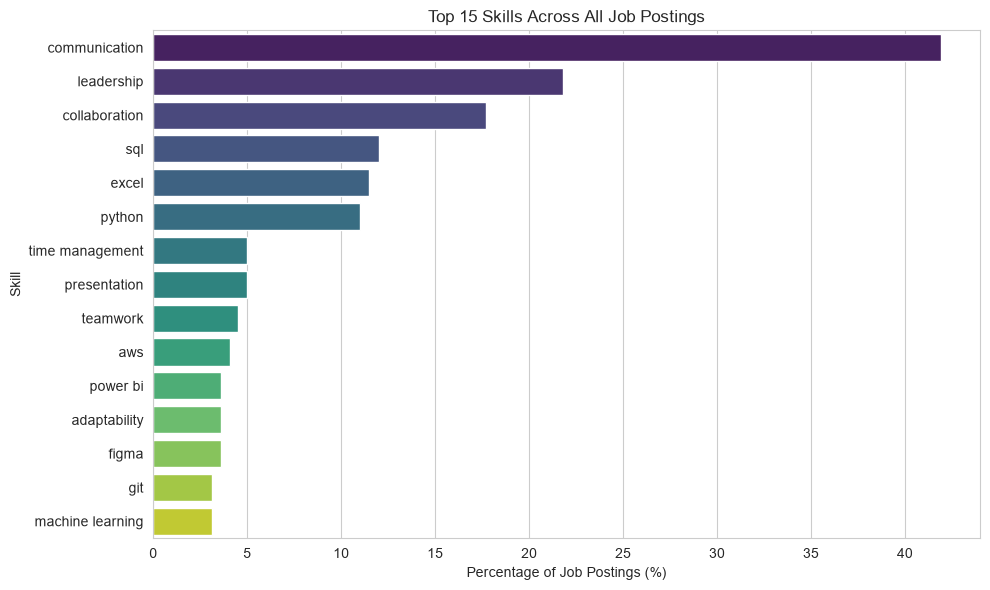

In [22]:
top_n = 15
top_skills = combined_percentages.head(top_n)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_skills.values, y=top_skills.index, hue=top_skills.index, palette="viridis", legend=False)
plt.xlabel("Percentage of Job Postings (%)")
plt.ylabel("Skill")
plt.title(f"Top {top_n} Skills Across All Job Postings")
plt.tight_layout() #prevents labels from getting cut off at the figure edges
plt.savefig("../visuals/top_skills_overall.png", dpi=150)
plt.show()

##### **Key insights**:

**Soft skills are mentioned more often than technical skills.** The most common soft skill, Communication, appeared in 41.9% of all job postings. This is more than three times higher than the most frequently mentioned technical skill, SQL, which appeared in 12.0% of the postings.

This is mainly because the dataset includes many non-technical and generalist roles, such as Product, Marketing, Administrative, and Operations positions. These types of jobs often place greater importance on interpersonal and communication skills rather than specific technical tools or programming skills.

#### Top Technical 15 Skills

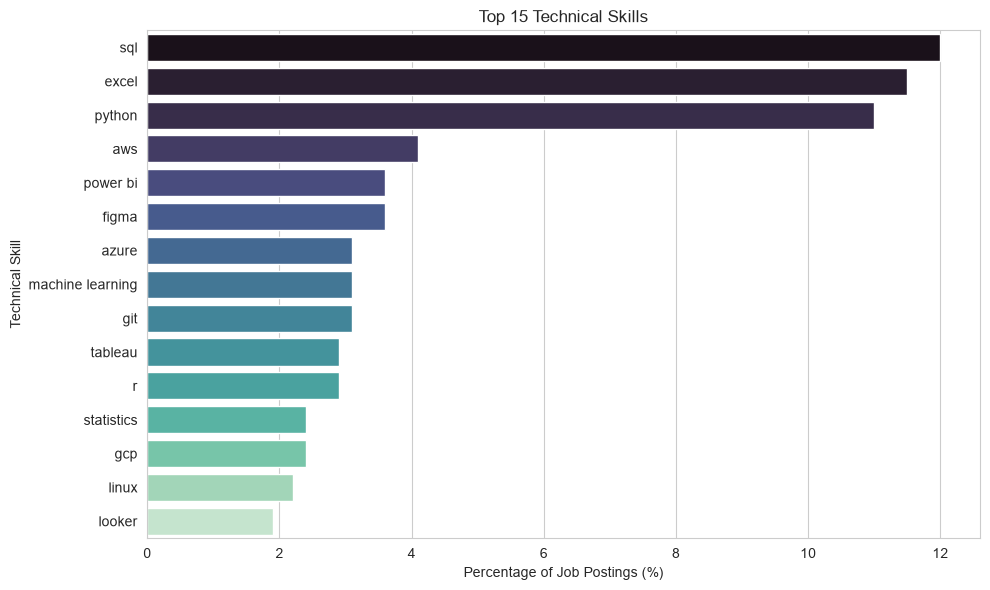

In [23]:
top_technical = skill_percentages.head(top_n)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_technical.values, y=top_technical.index, hue=top_technical.index, palette="mako", legend=False)
plt.xlabel("Percentage of Job Postings (%)")
plt.ylabel("Technical Skill")
plt.title(f"Top {top_n} Technical Skills")
plt.tight_layout()
plt.savefig("../visuals/top_technical_skills.png", dpi=150)
plt.show()

#### Step 3 - Classify job titles into role categories

In [24]:
def classify_role(title):
    title = title.lower()
    if " data scientist" in title:
        return "Data Scientist"
    elif "analyst" in title:
        return "Data Analyst"
    elif "engineer" in title:
        return "Engineer"
    elif "designer" in title:
        return "Designer"
    elif "marketing" in title:
        return "Marketing"
    elif "scientist" in title:
        return "Scientist"
    elif "product" in title:
        return "Product"
    else:
        return "Other"

df["role_category"] = df["title"].apply(classify_role)
df["role_category"].value_counts()

role_category
Other             261
Product            44
Designer           34
Data Analyst       31
Engineer           27
Marketing          13
Scientist           5
Data Scientist      3
Name: count, dtype: int64

The count in 'Other' category is too high. The number of 'Data Scientist' postings are only 3, which is too low, and any comparisons against it
would be meaningless. Therefore in order to fix this issue, we first need to identify what are the actual job titles getting missed.

In [25]:
df[df["role_category"] == "Other"]["title"].value_counts().head(30)

title
supply &amp; logistics coordinator                            7
executive assistant                                           6
technical writer                                              6
data entry clerk                                              3
backend developer                                             3
entry level administrative assistant                          3
data entry specialist assistant administrator                 2
technical project manager                                     2
data entry                                                    2
assistant store manager                                       2
data processing specialist                                    2
customer support                                              2
event planning assistant                                      2
vice president of operations                                  2
bid manager                                                   2
administrative data entry file cle

There's an HTML entity leak; 'supply & amp; logistics coordinator' the & amp; should have decoded to &. The title column did not went through the same cleaning the description column did. The title column came straight from the API's position field.

Also there're non-english rows that don't belong to a meaningful analysis, therefore need to filter them out as well.

#### **Fix the HTML entity leak in title**

In [28]:
import html

df["title"] = df["title"].apply(html.unescape) #converts HTML entities to normal characters

In [30]:
df["company"] = df["company"].apply(html.unescape) #does the same for the company column

#### **Filter out non-English titles**

In [31]:
before = len(df)
df = df[df["title"].str.match(r"^[a-zA-Z0-9\s\-\&\/\(\)\.,'’]+$", na=False)]
after = len(df)
print(f"Removed {before - after} non-English/garbage title rows")

Removed 13 non-English/garbage title rows


#### **Expand the classifier with the new categories you found**

In [32]:
role_keywords = [
    ("data scientist", "Data Scientist"),
    ("data analyst", "Data Analyst"),
    ("data engineer", "Data Engineer"),
    ("data entry", "Data Entry"),
    ("data processing", "Data Entry"),
    ("machine learning", "Data Scientist"),
    ("scientist", "Data Scientist"),
    ("analyst", "Data Analyst"),
    ("software engineer", "Engineer"),
    ("backend", "Engineer"),
    ("frontend", "Engineer"),
    ("full stack", "Engineer"),
    ("devops", "Engineer"),
    ("engineer", "Engineer"),
    ("developer", "Engineer"),
    ("designer", "Designer"),
    ("ux", "Designer"),
    ("ui", "Designer"),
    ("marketing", "Marketing"),
    ("seo", "Marketing"),
    ("content", "Marketing"),
    ("product manager", "Product"),
    ("product", "Product"),
    ("sales", "Sales"),
    ("customer support", "Customer Support"),
    ("customer", "Customer Support"),
    ("support", "Customer Support"),
    ("technical writer", "Technical Writing"),
    ("writer", "Technical Writing"),
    ("executive assistant", "Administrative"),
    ("administrative", "Administrative"),
    ("assistant", "Administrative"),
    ("coordinator", "Operations"),
    ("logistics", "Operations"),
    ("operations", "Operations"),
    ("procurement", "Operations"),
    ("project manager", "Project Management"),
    ("hr", "HR"),
    ("human resources", "HR"),
    ("recruiter", "HR"),
    ("finance", "Finance"),
    ("accountant", "Finance"),
]

def classify_role(title):
    title = title.lower()
    for keyword, category in role_keywords:
        if keyword in title:
            return category
    return "Other"

df["role_category"] = df["title"].apply(classify_role)
df["role_category"].value_counts()

role_category
Other                 139
Product                41
Designer               35
Engineer               35
Data Analyst           31
Operations             29
Administrative         20
Marketing              15
Data Entry             14
Customer Support       11
Data Scientist          8
HR                      6
Sales                   6
Technical Writing       6
Project Management      4
Data Engineer           4
Finance                 1
Name: count, dtype: int64

##### **Key insights**:

**The dataset contains more non-technical and generalist jobs than data-specific jobs.** Out of 418 job postings, 139 postings (33%) were classified as "Other", making it the largest category. This was followed by Product roles (41 postings) and Designer roles (35 postings).

In comparison, data-related roles, including Data Analyst, Data Scientist, and Data Engineer positions made up only about 17% of all postings.

This happened because the jobs were scraped using a mix of search tags, including data, Python, SQL, marketing, design, and product, rather than focusing only on data-related jobs. Therefore, the results represent a broader job market and should not be treated as a complete or fully accurate representation of the data job market specifically.

#### **Re-check 'Other' count and inspect what's left**

In [33]:
print(df["role_category"].value_counts())
df[df["role_category"] == "Other"]["title"].value_counts().head(20)

role_category
Other                 139
Product                41
Designer               35
Engineer               35
Data Analyst           31
Operations             29
Administrative         20
Marketing              15
Data Entry             14
Customer Support       11
Data Scientist          8
HR                      6
Sales                   6
Technical Writing       6
Project Management      4
Data Engineer           4
Finance                 1
Name: count, dtype: int64


title
bid manager                                                    2
nurse advice swing shift 5a 10a 10p 5a cst                     1
social media video editor                                      1
college counselor                                              1
english language expert                                        1
ispettore broker ramo danni                                    1
manufacturing operator i                                       1
no experience                                                  1
online online appointment setter booking hotels entry level    1
manufacturing manager                                          1
key account executive pro                                      1
projeteur vrd f h                                              1
maintenance & repair technician senior                         1
scrum master                                                   1
payroll specialist                                             1
document specialist

#### **Save the final skills set + roles dataset**

In [34]:
df.to_csv("../data/skills_data.csv", index=False)
print(f"Final dataset: {len(df)} rows, {len(df.columns)} columns")

Final dataset: 405 rows, 50 columns


#### **Confirm group sizes before charting**

In [35]:
df["role_category"].value_counts()[["Data Analyst", "Data Scientist", "Data Engineer", "Engineer"]]

role_category
Data Analyst      31
Data Scientist     8
Data Engineer      4
Engineer          35
Name: count, dtype: int64

#### Step 4 — Compare skill frequency: Data Analyst vs Data Scientist AND Data Analyst vs Engineer

In [41]:
analyst_df = df[df["role_category"] == "Data Analyst"]
engineer_df = df[df["role_category"] == "Engineer"]
scientist_df = df[df["role_category"] == "Data Scientist"]
dataeng_df = df[df["role_category"]== "Data Engineer"]

analyst_pct = (analyst_df[technical_skills].sum() / len(analyst_df) * 100).round(1) #percent of analyst postings mentioning the specific technical skills
engineer_pct = (engineer_df[technical_skills].sum() / len(engineer_df) * 100).round(1)
scientist_pct = (scientist_df[technical_skills].sum() / len(scientist_df) * 100).round(1)
dataeng_pct = (dataeng_df[technical_skills].sum() / len(dataeng_df)*100).round(1)

comparison_main = pd.DataFrame({
    "Data Analyst (%)": analyst_pct,
    "Engineer (%)": engineer_pct
}).sort_values("Data Analyst (%)", ascending=False)

comparison_secondary = pd.DataFrame({
    "Data Analyst (%)": analyst_pct,
    "Data Scientist (%)": scientist_pct
}).sort_values("Data Analyst (%)", ascending=False)

comparison_ternary = pd.DataFrame({
    "Data Scientist (%)": scientist_pct,
    "Data Engineer (%)": dataeng_pct
}).sort_values("Data Scientist (%)", ascending=False)

print(comparison_main.head(10))
print(comparison_secondary.head(10))
print(comparison_ternary.head(10))

            Data Analyst (%)  Engineer (%)
sql                     58.1          51.4
excel                   48.4           2.9
python                  35.5          48.6
power bi                35.5           0.0
tableau                 32.3           0.0
statistics              22.6           0.0
looker                  19.4           2.9
r                       12.9           5.7
azure                    9.7          17.1
git                      9.7          11.4
            Data Analyst (%)  Data Scientist (%)
sql                     58.1                25.0
excel                   48.4                 0.0
python                  35.5                25.0
power bi                35.5                12.5
tableau                 32.3                 0.0
statistics              22.6                25.0
looker                  19.4                 0.0
r                       12.9                 0.0
azure                    9.7                 0.0
git                      9.7         

#### Step 5 - Chart 1: Data Analyst vs Engineer top 10 skills

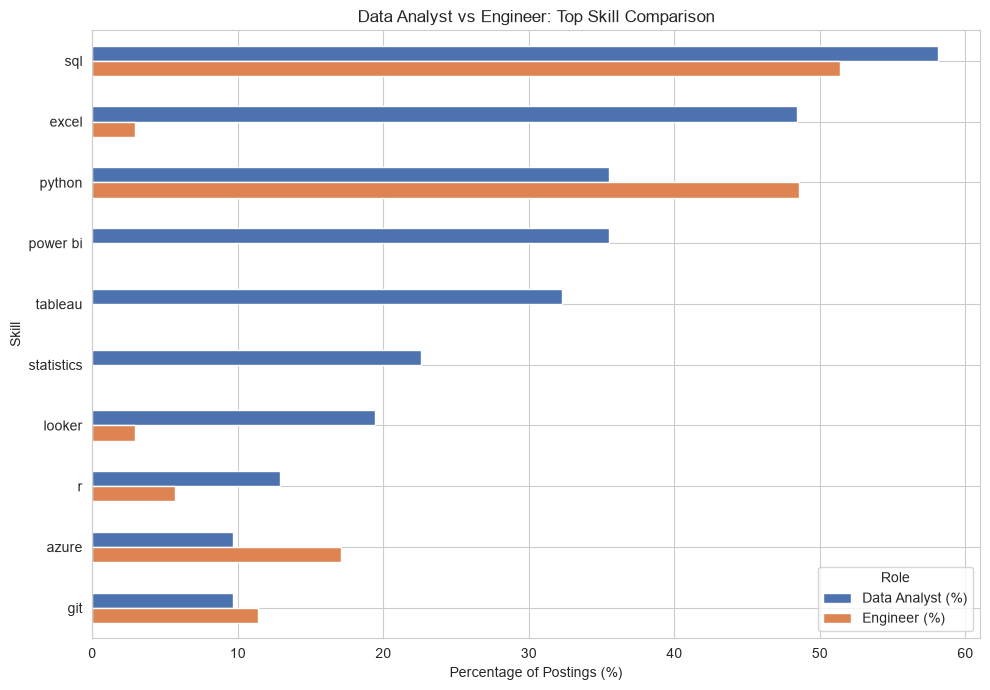

In [38]:
top_compare_main = comparison_main.head(10)

top_compare_main.plot(kind="barh", figsize=(10, 7), color=["#4C72B0", "#DD8452"])
plt.xlabel("Percentage of Postings (%)")
plt.ylabel("Skill")
plt.title("Data Analyst vs Engineer: Top Skill Comparison")
plt.legend(title="Role")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../visuals/analyst_vs_engineer.png", dpi=150)
plt.show()

##### **Key Insights**:

1. **Excel is an Analyst-specific skill, not a general one.** Excel appeared in 
   48.4% of Data Analyst postings but only 2.9% of Engineer postings, a 45.5 
   percentage-point gap, the largest of any skill compared across these two roles.

2. **BI and data visualization tools are mainly required for Analyst roles.** Power BI (35.5%), Tableau (32.3%), and Looker (19.4%) appeared in at least a third of Data Analyst job postings, but were mentioned in almost 0% of Engineer postings. This shows that dashboarding and visualization tools are mainly Analyst-specific skills, rather than skills generally required in Engineer roles.

3. **Python is more evenly spread than SQL across technical roles.** Python 
   appeared in 35.5% of Analyst postings and 48.6% of Engineer postings,
   fairly balanced, while SQL, despite being the single most common skill 
   overall, is far more concentrated in Analyst work (58.1%) than Engineering 
   (51.4%, still high, but a smaller gap than Excel or BI tools).

#### Step 6 - Chart 2: Data Analyst vs Data Scientist top 10 skills (with limitations)

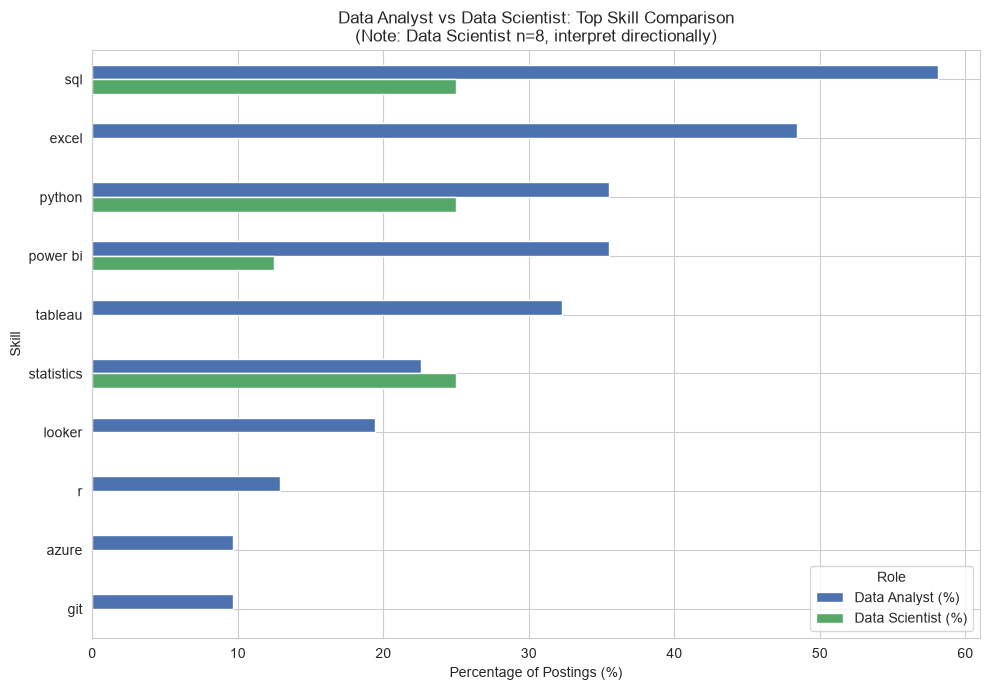

In [43]:
top_compare_secondary = comparison_secondary.head(10)

top_compare_secondary.plot(kind="barh", figsize=(10, 7), color=["#4C72B0", "#55A868"])
plt.xlabel("Percentage of Postings (%)")
plt.ylabel("Skill")
plt.title("Data Analyst vs Data Scientist: Top Skill Comparison\n(Note: Data Scientist n=8, interpret directionally)")
plt.legend(title="Role")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../visuals/analyst_vs_scientist.png", dpi=150)
plt.show()

#### Step 7 - Chart 2: Data Scientist vs Data Engineer top 10 skills (with limitations)

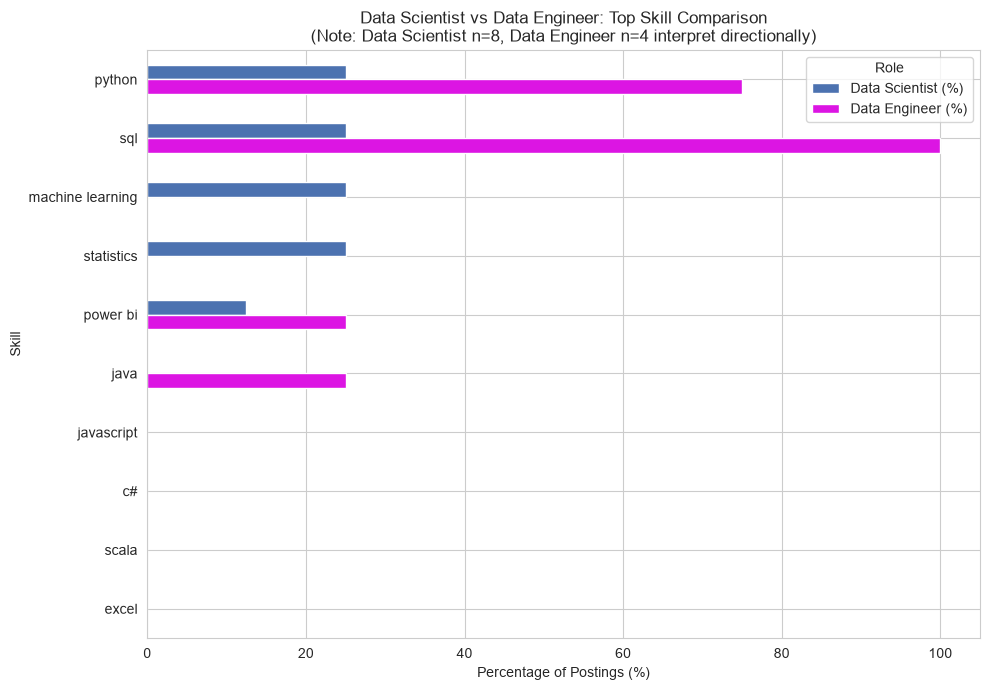

In [42]:
top_compare_ternary = comparison_ternary.head(10)

top_compare_ternary.plot(kind="barh", figsize=(10, 7), color=["#4C72B0", "#DC15E3"])
plt.xlabel("Percentage of Postings (%)")
plt.ylabel("Skill")
plt.title("Data Scientist vs Data Engineer: Top Skill Comparison\n(Note: Data Scientist n=8, Data Engineer n=4 interpret directionally)")
plt.legend(title="Role")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../visuals/scientist_vs_data_engineer.png", dpi=150)
plt.show()

##### **Key insights**:

**Directional signal only - small sample:** among the very few Data Engineer 
   (4) and Data Scientist (8) postings collected, SQL and Python appeared 
   in 100% and 75% of Data Engineer listings respectively, versus 25% each for 
   Data Scientist. Given the small sample size, this should be read as a 
   hint worth investigating further, not a confident market conclusion.

#### Step 8 - Print final group sizes for your records

In [46]:
print("Data Analyst postings:", len(analyst_df))
print("Engineer postings:", len(engineer_df))
print("Data Scientist postings:", len(scientist_df))
print("Data Engineer postings:", len(dataeng_df))

Data Analyst postings: 31
Engineer postings: 35
Data Scientist postings: 8
Data Engineer postings: 4


#### Step 9 - soft vs technical balance by role

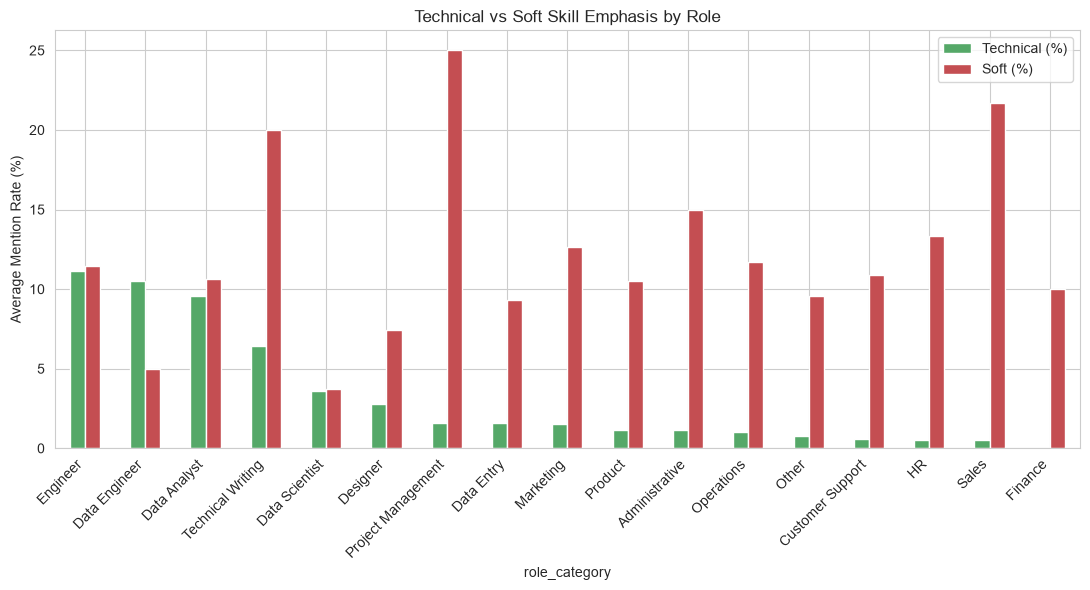

In [45]:
role_soft_tech = df.groupby("role_category").apply(
    lambda x: pd.Series({
        "Technical (%)": (x[technical_skills].sum().sum() / (len(x) * len(technical_skills)) * 100),
        "Soft (%)": (x[soft_skills].sum().sum() / (len(x) * len(soft_skills)) * 100)
    })
)

role_soft_tech.sort_values("Technical (%)", ascending=False).plot(
    kind="bar", figsize=(11, 6), color=["#55A868", "#C44E52"]
)
plt.ylabel("Average Mention Rate (%)")
plt.title("Technical vs Soft Skill Emphasis by Role")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../visuals/technical_vs_soft_by_role.png", dpi=150)
plt.show()

#### **Summary**

Across 418 scraped job postings, soft skills, especially communication were mentioned more often than any single technical skill, mainly because the dataset includes a wide mix of roles. Among technical roles, SQL was the most consistently required skill for both Data Analysts and Data Engineers. In contrast, Excel and BI tools such as Power BI, Tableau, and Looker were much more common in Analyst roles and almost absent from Engineering roles, showing a clear difference between "engineering and data analyzing roles.